# MuJoCo Two-Finger Push 实验复现

本 Notebook 用于在服务器上复现 `mujoco_two_finger_push` 任务的两个对比实验：
1. **Baseline**: 使用标准 `DiffusionTransformerPolicy`。
2. **AttnRes**: 使用带有残差注意力机制的 `AttnResDiffusionTransformerPolicy`。

我们将通过远程 Jupyter Kernel 在服务器上运行训练，并可视化对比结果。

In [6]:
# Cell 1: 环境初始化
import sys, os
import torch
import pandas as pd
import matplotlib.pyplot as plt

# 设置服务器上的项目根目录路径
PROJECT_ROOT = "/root/autodl-tmp/ROBOTICS_CS461EX1_Task"
if os.path.exists(PROJECT_ROOT):
    sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)
    print(f"已切换到项目根目录: {os.getcwd()}")
else:
    print(f"警告: 未找到路径 {PROJECT_ROOT}，请确认是否连接到远程 Kernel。")

# 检查 CUDA 是否可用
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"当前使用的设备: {device}")

已切换到项目根目录: /root/autodl-tmp/ROBOTICS_CS461EX1_Task
当前使用的设备: cuda


In [7]:
%%bash
source /root/miniconda3/etc/profile.d/conda.sh
conda activate mujoco
export MUJOCO_GL=egl
export HF_ENDPOINT=https://hf-mirror.com

echo "开始运行 Baseline 实验..."
python -c "from src.trainers.baseline_trainer import run_training; run_training('configs/mujoco_push_a4_tuned.yaml')"

开始运行 Baseline 实验...
[Epoch 01 Done] train_mse=0.776307 val_mse=0.112247 val_success=0.0000
[Epoch 02 Done] train_mse=0.053390 val_mse=0.018156 val_success=0.2160
[Epoch 03 Done] train_mse=0.023033 val_mse=0.014893 val_success=0.7440
[Epoch 04 Done] train_mse=0.017001 val_mse=0.011911 val_success=0.8800
[Epoch 05 Done] train_mse=0.014829 val_mse=0.010028 val_success=0.8640
[Epoch 06 Done] train_mse=0.013319 val_mse=0.008386 val_success=0.9280
[Epoch 07 Done] train_mse=0.012226 val_mse=0.008104 val_success=0.9040
[Epoch 08 Done] train_mse=0.011625 val_mse=0.008021 val_success=0.9680
[Epoch 09 Done] train_mse=0.011657 val_mse=0.008275 val_success=0.8560
[Epoch 10 Done] train_mse=0.011478 val_mse=0.007688 val_success=0.9040
[Epoch 11 Done] train_mse=0.010571 val_mse=0.007029 val_success=0.9200
[Epoch 12 Done] train_mse=0.010165 val_mse=0.007501 val_success=0.9680
[Epoch 13 Done] train_mse=0.010048 val_mse=0.006685 val_success=0.9520
[Epoch 14 Done] train_mse=0.009920 val_mse=0.005945 val_s

In [8]:
%%bash
source /root/miniconda3/etc/profile.d/conda.sh
conda activate mujoco
export MUJOCO_GL=egl
export HF_ENDPOINT=https://hf-mirror.com

echo "开始运行 AttnRes 实验..."
python -c "from src.trainers.baseline_trainer import run_training; run_training('configs/mujoco_push_a4_attnres.yaml')"

开始运行 AttnRes 实验...
[Epoch 01 Done] train_mse=0.396090 val_mse=0.085834 val_success=0.0000
[Epoch 02 Done] train_mse=0.042530 val_mse=0.016006 val_success=0.6480
[Epoch 03 Done] train_mse=0.019094 val_mse=0.013808 val_success=0.7600
[Epoch 04 Done] train_mse=0.015397 val_mse=0.009808 val_success=0.8640
[Epoch 05 Done] train_mse=0.012879 val_mse=0.008508 val_success=0.9280
[Epoch 06 Done] train_mse=0.012090 val_mse=0.007897 val_success=0.9200
[Epoch 07 Done] train_mse=0.011109 val_mse=0.007509 val_success=0.9280
[Epoch 08 Done] train_mse=0.010646 val_mse=0.007840 val_success=0.9760
[Epoch 09 Done] train_mse=0.010738 val_mse=0.007239 val_success=0.9600
[Epoch 10 Done] train_mse=0.010363 val_mse=0.006498 val_success=0.9440
[Epoch 11 Done] train_mse=0.009469 val_mse=0.006774 val_success=0.9600
[Epoch 12 Done] train_mse=0.008922 val_mse=0.006311 val_success=1.0000
[Epoch 13 Done] train_mse=0.009229 val_mse=0.006019 val_success=0.9520
[Epoch 14 Done] train_mse=0.008294 val_mse=0.005671 val_su

In [9]:
# Cell 4: 加载实验结果
import pandas as pd
import os

results_dir = "results"
tuned_csv = os.path.join(results_dir, "mujoco_push_a4_tuned", "metrics.csv")
attnres_csv = os.path.join(results_dir, "mujoco_push_a4_attnres", "metrics.csv")

def load_metrics(path):
    if os.path.exists(path):
        return pd.read_csv(path)
    else:
        print(f"文件不存在: {path}")
        return None

df_tuned = load_metrics(tuned_csv)
df_attnres = load_metrics(attnres_csv)

if df_tuned is not None and df_attnres is not None:
    print("成功加载两个实验的指标数据。")

成功加载两个实验的指标数据。


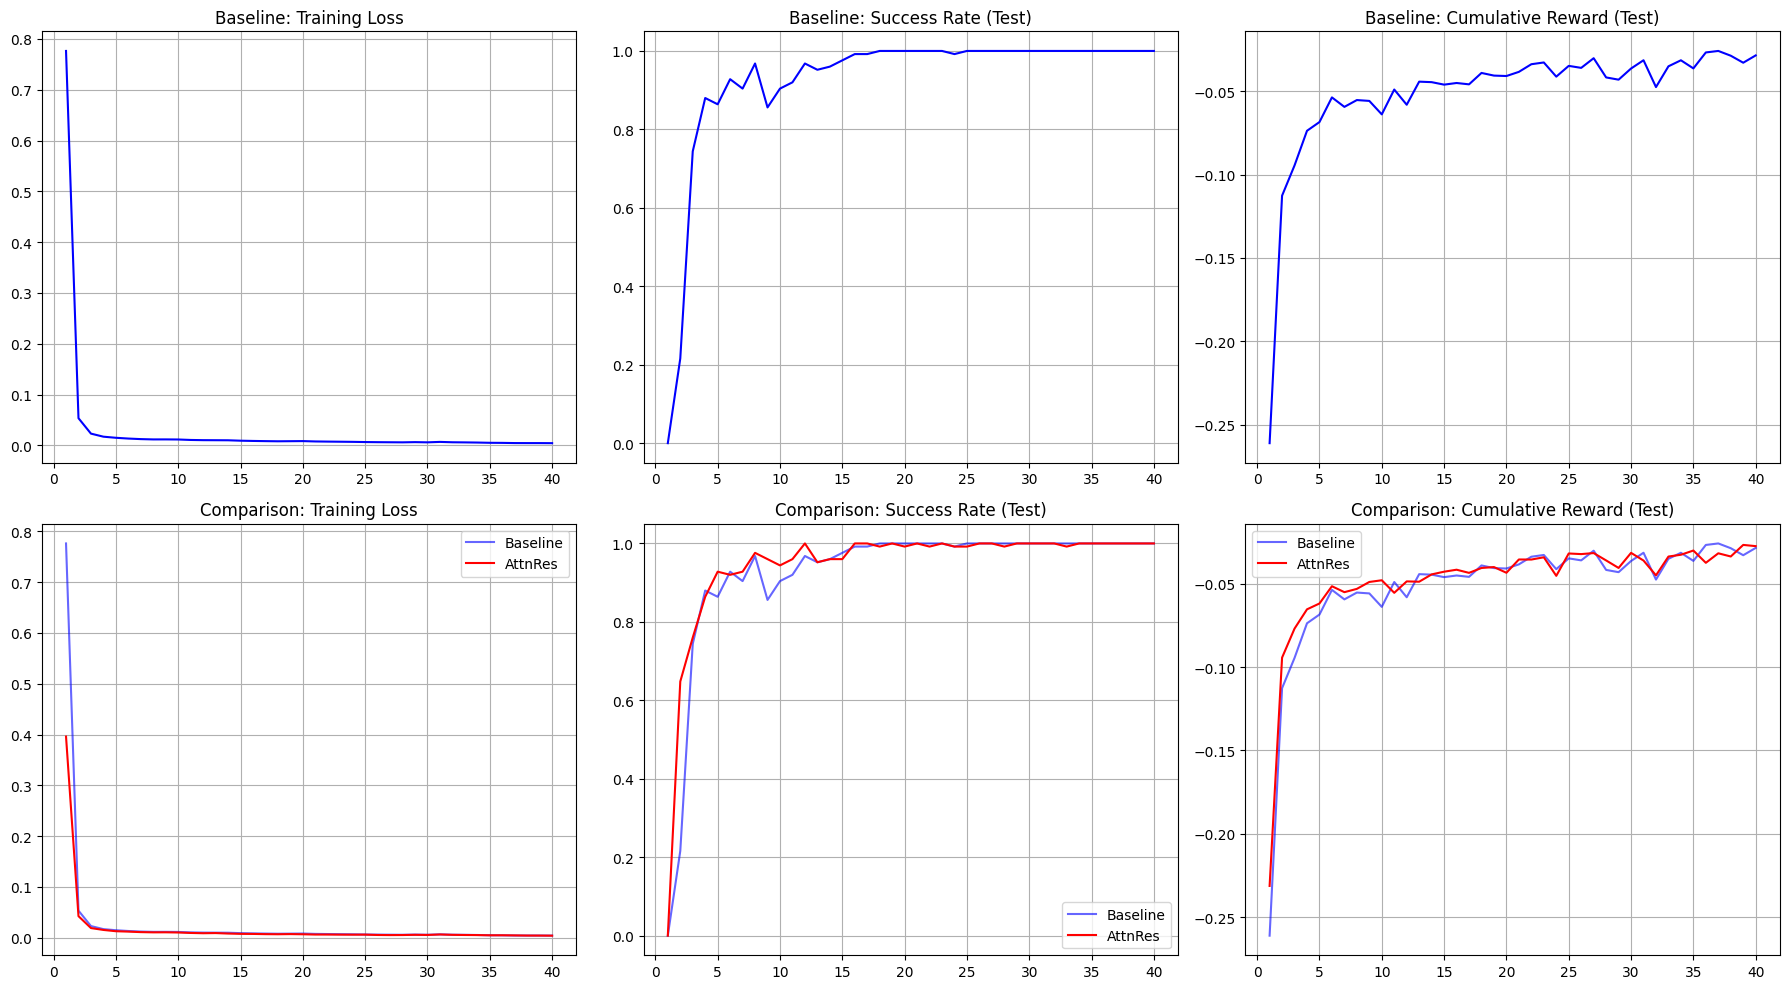

In [10]:
# Cell 5: 对比绘图
if df_tuned is not None and df_attnres is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    metrics = ['train_mse', 'val_success_rate', 'val_cumulative_reward']
    titles = ['Training Loss', 'Success Rate (Test)', 'Cumulative Reward (Test)']
    
    for i, metric in enumerate(metrics):
        # 第一行：Baseline
        axes[0, i].plot(df_tuned['epoch'], df_tuned[metric], label='Baseline', color='blue')
        axes[0, i].set_title(f"Baseline: {titles[i]}")
        axes[0, i].grid(True)
        
        # 第二行：对比
        axes[1, i].plot(df_tuned['epoch'], df_tuned[metric], label='Baseline', color='blue', alpha=0.6)
        axes[1, i].plot(df_attnres['epoch'], df_attnres[metric], label='AttnRes', color='red')
        axes[1, i].set_title(f"Comparison: {titles[i]}")
        axes[1, i].legend()
        axes[1, i].grid(True)
    
    plt.tight_layout()
    plt.show()

In [11]:
# Cell 6: 最终指标汇总表格
if df_tuned is not None and df_attnres is not None:
    last_tuned = df_tuned.iloc[-1]
    last_attnres = df_attnres.iloc[-1]
    
    summary = pd.DataFrame({
        'Metric': ['Epoch', 'Train Loss', 'Success Rate', 'Avg Reward'],
        'Baseline': [last_tuned['epoch'], last_tuned['train_mse'], last_tuned['val_success_rate'], last_tuned['val_cumulative_reward']],
        'AttnRes': [last_attnres['epoch'], last_attnres['train_mse'], last_attnres['val_success_rate'], last_attnres['val_cumulative_reward']]
    })
    
    print("--- 最终指标对比 (Epoch 40) ---")
    display(summary)

--- 最终指标对比 (Epoch 40) ---


,Metric,Baseline,AttnRes
0,Epoch,40.000000,40.000000
1,Train Loss,0.004246,0.004126
2,Success Rate,1.000000,1.000000
3,Avg Reward,-0.028494,-0.027423
